# Sidebar — the AUROR vehicle as a point source, distilled from the real mesh

The AUROR_ref vehicle (`hypersonic.obj`, ~2 m) sits 500 km below a sensor with 16 m pixels. It
covers about 0.3 % of one pixel. As received, it also adds no light at all, so it never shows up
(FINDINGS.md, 2026-10-09). The stage 02 notebook works around that with an oversized disk. This
sidebar instead asks what the *real* mesh would contribute if it reflected sunlight. It answers
with DIRSIG's own renderer and hands the answer back to DIRSIG as a point source:

1. give the mesh a nonzero reflectance (a new material; the received one is untouched);
2. render it at close range, with the sun and the view direction exactly as in the AUROR task,
   and no meaningful atmosphere between the close sensor and the mesh;
3. integrate that radiance map into a radiant intensity $I(\lambda)$ in W sr⁻¹ µm⁻¹;
4. write $I(\lambda)$ to a `.int` file, define a GLIST point source with it, and render the full
   AUROR scene with that source riding on the vehicle's motion.

Along the way it renders the received emitter with DIRSIG's thermal prediction forced on. That
tests FINDINGS.md's original "+49 %" expectation for the 1500 K vehicle directly.

This is exploratory work, not a stage or a tutorial. `config_repo/` is read, never written: each
job is submitted against a mirror of it under `outputs/sidebar_vehicle_point_source/`, with every
file a symlink to the original, plus the few files a pass needs. The assets this notebook adds
are in `notebooks/sidebars/vehicle_point_source/`.

| Pass | Sensor | Scene change | Purpose |
|---|---|---|---|
| A | 1 km above the vehicle, spectral radiance | vehicle → `Gidder_mat_reflective` (ρ = 0.30) | $I(\lambda)$, reflected |
| B | same as A | none (received `Gidder_mat`), thermal forced on | received emitter, close up |
| C | AUROR, 500 km | none | baseline, seed 42 |
| D | AUROR, 500 km | + point source on the vehicle's motion | the distilled vehicle |
| E | AUROR, 500 km | none, thermal forced on | the "+49 %" test |

## Environment

In [1]:
import copy
import os
import shutil
import sys
from pathlib import Path

import lxml.etree as et
import matplotlib.pyplot as plt
import numpy as np
import yaml
from spectral import open_image

DEFAULT_DIRSIG_HOME = Path.home() / "DIRSIG" / "dirsig-2026.38.0.a020954-Linux-x86_64"
DIRSIG_HOME = Path(os.environ.get("DIRSIG_HOME", DEFAULT_DIRSIG_HOME)).expanduser()
os.environ["DIRSIG_HOME"] = str(DIRSIG_HOME)
os.environ["PATH"] = f"{DIRSIG_HOME / 'bin'}{os.pathsep}" + os.environ.get("PATH", "")
assert shutil.which("scene2hdf") and shutil.which("dirsig5"), "DIRSIG binaries not on PATH"

PROJECT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file())   # repo root, from any depth
try:
    import protodirsig
except ImportError:
    sys.path.insert(0, str(PROJECT / "src"))
    import protodirsig
from protodirsig.scene_ref import fingerprint
from protodirsig.simulation import Simulation

CONFIG_REPO = PROJECT / "config_repo"                  # read-only engine-asset library
RUN_SPEC = PROJECT / "run_specs" / "auror_ref.yaml"
ASSETS = PROJECT / "notebooks" / "sidebars" / "vehicle_point_source"
WORK = PROJECT / "outputs" / "sidebar_vehicle_point_source"
SCENE_DIR = Path("scenes/tahoe")
BUNDLE = CONFIG_REPO / SCENE_DIR / "geometry/bundles/hypersonic"
if WORK.exists():
    shutil.rmtree(WORK)                                 # our own directory; rmtree unlinks symlinks, never follows them
WORK.mkdir(parents=True)
REPO_BEFORE = fingerprint(CONFIG_REPO)
print("DIRSIG_HOME:", DIRSIG_HOME)
print("work dir   :", WORK.relative_to(PROJECT))

DIRSIG_HOME: /home/kevin-kearney/DIRSIG/dirsig-2026.38.0.a020954-Linux-x86_64
work dir   : outputs/sidebar_vehicle_point_source


## The numbers, re-derived from the files

The sensor's pixel footprint at the vehicle is pitch ÷ focal length × range. Pitch and focal
length come from the library platform file. The range is the run spec's sensor height minus the
vehicle's start height in `lists/hypersonic.glist`. Both share x, y = (−400, 400), so the
vehicle is straight below the sensor.

The mesh's silhouette seen from above is computed by rasterizing every face of `hypersonic.obj`,
projected onto x–y, on a 2 mm grid. The vehicle's `velocity` orientation engine keeps the model's
+Z up, so this top-down area is the area the overhead sensor sees, whatever the heading.

In [2]:
from matplotlib.path import Path as MplPath

plat = et.parse(str(CONFIG_REPO / "platforms/AurorNIRDetector/AurorNIRDetector.platform")).getroot()
FOCAL = float(plat.findtext(".//instrument/properties/focallength")) * 1e-3     # m
PITCH = float(plat.findtext(".//detectorarray/xelementsize")) * 1e-6            # m
IFOV = PITCH / FOCAL                                                            # rad
ch = plat.find(".//channellist/channel")
CH_CENTER, CH_SIGMA = float(ch.findtext("center")), float(ch.findtext("width"))
vehicle_glist = et.parse(str(CONFIG_REPO / SCENE_DIR / "geometry/lists/hypersonic.glist")).getroot()
start = vehicle_glist.find(".//locationengine/start")
VEHICLE = np.array([float(start.findtext(k)) for k in "xyz"])
spec = yaml.safe_load(RUN_SPEC.read_text())
SENSOR = np.array(spec["engine"]["motion"]["position"]["xyz"], dtype=float)
RANGE = SENSOR[2] - VEHICLE[2]
GSD = IFOV * RANGE
assert np.allclose(SENSOR[:2], VEHICLE[:2])

verts, faces = [], []
for line in (BUNDLE / "hypersonic.obj").read_text().splitlines():
    if line.startswith("v "):
        verts.append([float(v) for v in line.split()[1:4]])
    elif line.startswith("f "):
        faces.append([int(v.split("/")[0]) - 1 for v in line.split()[1:]])
verts = np.array(verts)
h = 0.002
lo, hi = verts[:, :2].min(0), verts[:, :2].max(0)
gx, gy = np.meshgrid(np.arange(lo[0], hi[0], h) + h / 2, np.arange(lo[1], hi[1], h) + h / 2)
pts = np.c_[gx.ravel(), gy.ravel()]
inside = np.zeros(len(pts), bool)
for f in faces:
    p = verts[f][:, :2]
    sel = ~inside & np.all(pts >= p.min(0), axis=1) & np.all(pts <= p.max(0), axis=1)
    if sel.any():
        inside[np.flatnonzero(sel)[MplPath(p).contains_points(pts[sel])]] = True
A_TOP = inside.sum() * h * h

print(f"mesh: {len(verts)} vertices, {len(faces)} faces, extent {np.ptp(verts, axis=0).round(3)} m")
print(f"IFOV {PITCH * 1e6:.0f} um / {FOCAL * 1e3:.0f} mm = {IFOV * 1e6:.2f} urad; range {RANGE:.0f} m "
      f"-> {GSD:.2f} m pixels ({GSD**2:.1f} m^2)")
print(f"top-down silhouette {A_TOP:.3f} m^2 = {A_TOP / GSD**2:.2%} of one pixel")
print(f"AUROR channel: Gaussian, centre {CH_CENTER} um, width (sigma) {CH_SIGMA:.4f} um")

mesh: 9227 vertices, 9224 faces, extent [2.004 0.989 0.288] m
IFOV 10 um / 306 mm = 32.68 urad; range 500000 m -> 16.34 m pixels (267.0 m^2)
top-down silhouette 0.827 m^2 = 0.31% of one pixel
AUROR channel: Gaussian, centre 0.85 um, width (sigma) 0.0637 um


## Building jobs against a mirror of `config_repo/`

Every pass is an ordinary `Simulation` of the AUROR run spec (or a copy with the sensor moved),
submitted against a library mirror: real directories, and every file a symlink to its original
in `config_repo/`. A pass swaps or adds a few files in its own mirror. Replacing a file deletes
the *symlink* and writes a real file in its place, so the original is never opened for writing.
`config_repo/` is fingerprinted at the start and checked at the end.

Passes B and E need one `dirsig5` flag that `Simulation.run()` doesn't pass,
`--force_temperature_prediction`. `run_with` therefore assembles the job with the same
`Simulation._assemble` that `run()` uses, and calls dirfm's `DIRSIG.run` with the extra flag.

In [3]:
def mirror(name):
    """A fresh mirror of config_repo/ under WORK/<name>/library."""
    lib = WORK / name / "library"
    for d, _, files in os.walk(CONFIG_REPO):
        rel = Path(d).relative_to(CONFIG_REPO)
        (lib / rel).mkdir(parents=True, exist_ok=True)
        for f in files:
            (lib / rel / f).symlink_to(Path(d) / f)
    return lib


def put(path, data):
    """Write `data` (text, or an lxml tree) at `path`, replacing a symlink rather than its target."""
    path = Path(path)
    if path.is_symlink():
        path.unlink()
    path.parent.mkdir(parents=True, exist_ok=True)
    if isinstance(data, str):
        path.write_text(data)
    else:
        data.write(str(path), pretty_print=True)


def spec_with_sensor_at(name, z):
    """A copy of the run spec with only the sensor height changed, beside a link to sensors/."""
    d = WORK / name / "spec"
    d.mkdir(parents=True, exist_ok=True)
    (d / "sensors").symlink_to(RUN_SPEC.parent / "sensors", target_is_directory=True)
    s = copy.deepcopy(spec)
    s["engine"]["motion"]["position"]["xyz"][2] = float(z)
    (d / "auror_ref.yaml").write_text(yaml.safe_dump(s, sort_keys=False))
    return d / "auror_ref.yaml"


def run_with(name, library, run_spec=RUN_SPEC, **flags):
    """Render one pass; returns its output directory."""
    sim = Simulation(run_spec, library, WORK / name / "job")
    assert sim.auror_run is not None, sim.load_error or sim.resolve_error
    if not flags:
        return sim.run().output_dir
    out = sim.work_dir / "output"
    sim._assemble(sim.work_dir / "input", out).run(**flags)   # dirfm DIRSIG.run: None -> --flag
    return out


def load(out, stem):
    img = open_image(str(out / f"{stem}.img.hdr"))
    tr = open_image(str(out / "truth1.img.hdr"))
    truth = {n: np.asarray(tr.read_band(i), dtype=float) for i, n in enumerate(tr.metadata["band names"])}
    return np.asarray(img.load(), dtype=float), img.metadata, truth

---
# Pass A — the real mesh, reflective, at close range

**Reflectance.** No measured curve exists for this airframe. `ref_reflective.txt` is flat at
**0.30** at the same seven wavelengths as the received `ref.txt` (0.4–3.0 µm). 0.30 is the low end
of the plausible 0.3–0.8 range for a Lambertian stand-in. Hot airframe surfaces are normally
given high-emissivity (so low-reflectance) coatings, which argues for the low end, and a low
value doesn't flatter detectability. The reflected $I(\lambda)$ scales linearly with ρ for a
gray Lambertian surface, so another value is a rescale, not a re-render.

**A new material, not an edit.** `hypersonic_reflective.mat` is the received `hypersonic.mat`
with three lines changed: ID and NAME `Gidder_mat_reflective`, and `TXT_FILENAME =
ref_reflective.txt`. Temperature (1500 K `DataDriven`) and radiometry solver are unchanged.
`hypersonic_reflective.glist` loads the same `hypersonic.obj` (linked into the mirror, not
copied) and remaps its `usemtl Gidder_mat` to the new ID with `<assign>`. The reasons for not
editing `ref.txt` in place are in FINDINGS.md.

**Geometry.** The close sensor is the AUROR sensor moved straight down to 1 km above the vehicle:
same x, y, same orientation, same scene, epoch, NewAtmosphere database and SPICE ephemeris. The
vehicle keeps its own motion. So the sun direction (from DIRSIG's ephemeris at the scene origin
and epoch) and the view direction (straight down the scene's +Z, from directly above) are the
AUROR task's exactly. Only the range changes, and Lambertian radiance doesn't depend on range. At
1 km the AUROR IFOV gives 3.3 cm pixels, so the 2 m mesh is ~60 pixels long.

**No meaningful atmosphere.** The 1 km between the close sensor and the mesh lies at 50–51 km
altitude, where the air pressure is about 0.8 hPa (under 0.1 % of sea level). Over that slab the
Rayleigh optical depth at 0.85 µm is of order 10⁻⁶, and path radiance is negligible likewise.
The full-scene pass applies the real 50 → 550 km transmission to the point source itself. The
mesh's illumination (sun through the atmosphere above 50 km, sky, earthshine from the terrain
below) is the full scene's, because it is the same scene and atmosphere.

**The close sensor.** The AUROR platform with four changes:
- no aperture, so the output is at-aperture radiance;
- output in W m⁻² sr⁻¹ µm⁻¹, from 79 normalized 0.02 µm rectangular channels spanning
  0.41–1.99 µm, inside the AUROR bandpass;
- no temporal integration, so the 100 m/s vehicle doesn't smear across pixels;
- a 128 × 128 array.

The truth adds the `Gidder_mat_reflective` abundance (sub-pixel fill fraction), temperature,
sun fraction and sample count. Hypersampling is off; at this range the mesh is not sub-pixel.

In [4]:
CLOSE_RANGE = 1000.0
CENTERS = np.round(np.arange(0.42, 1.99, 0.02), 3)


def close_platform(material_id):
    p = copy.deepcopy(plat)
    props = p.find(".//instrument/properties")
    for k in ("aperturediameter", "aperturethroughput"):
        props.remove(props.find(k))
    cm = p.find(".//capturemethod")
    ss = cm.find("samplestrategy")
    ss.remove(ss.find("hypersamplingmultiplier"))
    cm.remove(cm.find("temporalintegration"))
    im = cm.find("imagefile")
    im.set("areaunits", "m2"); im.set("fluxunits", "watts"); im.find("basename").text = "close"
    channels = cm.find("spectralresponse/channellist")
    for c in list(channels):
        channels.remove(c)
    for c in CENTERS:
        e = et.SubElement(channels, "channel", bias="0", gain="1", name=f"{c:.2f}", normalize="true", shape="rectangular")
        et.SubElement(e, "center").text = f"{c:.3f}"
        et.SubElement(e, "width").text = "0.02"
        et.SubElement(e, "polarizer", type="none"); et.SubElement(e, "dataoutput", type="total")
    da = p.find(".//detectorarray")
    da.find("xelementcount").text = da.find("yelementcount").text = "128"
    tc = next(t for t in p.iter("truthcollection") if t.findtext("name") == "Collection 1")
    collectors = tc.find("collectorlist")
    for c in list(collectors):
        collectors.remove(c)
    for n in ("temperature", "sunshadow", "samplecount"):
        et.SubElement(et.SubElement(collectors, "collector"), "name").text = n
    ab = et.SubElement(collectors, "collector")
    et.SubElement(ab, "name").text = "Abundance"
    et.SubElement(ab, "materials").text = material_id
    return et.ElementTree(p)


def close_library(name, material_id, reflective):
    lib = mirror(name)
    put(lib / "platforms/AurorNIRDetector/AurorNIRDetector.platform", close_platform(material_id))
    if reflective:
        b = lib / SCENE_DIR / "geometry/bundles/hypersonic_reflective"
        for f in (ASSETS / "hypersonic_reflective").iterdir():
            put(b / f.name, f.read_text())
        (b / "hypersonic.obj").symlink_to(BUNDLE / "hypersonic.obj")
        g = copy.deepcopy(vehicle_glist)
        g.find(".//basegeometry/glist/filename").text = "bundles/hypersonic_reflective/hypersonic_reflective.glist"
        put(lib / SCENE_DIR / "geometry/lists/hypersonic.glist", et.ElementTree(g))
    return lib


close_spec = spec_with_sensor_at("A_close_reflective", VEHICLE[2] + CLOSE_RANGE)
out_A = run_with("A_close_reflective", close_library("A_close_reflective", "Gidder_mat_reflective", True), close_spec)
L_A, meta_A, truth_A = load(out_A, "close")
print(f"pass A: {L_A.shape}, {meta_A['data units']}; channels {CENTERS[0]}..{CENTERS[-1]} um")

Material [Dummy] ID has already been set to [N/A], can't override.


pass A: (128, 128, 79), watts/(m^2 sr um); channels 0.42..1.98 um


## Integrating the radiance map into $I(\lambda)$

Each pixel subtends Ω = IFOV² and, at range R, covers R²Ω of the plane through the vehicle. A
pixel with mesh fill fraction $f_i$ (the abundance truth) records
$L_i = f_i L_{\text{mesh},i} + (1-f_i)\,L_{\text{bg}}$. The background $L_{\text{bg}}(\lambda)$ is
the terrain 51 km below, the same in every pixel of this 4 m field. It is taken as the median over
pixels with $f=0$. So

$$I(\lambda) = R^2\Omega \sum_i f_i L_{\text{mesh},i} = R^2\Omega\Big[\sum_i L_i - L_{\text{bg}}\sum_i (1-f_i)\Big],
\qquad A_{\text{proj}} = R^2\Omega\sum_i f_i,\qquad \bar L = I / A_{\text{proj}}.$$

This is the prompt's "mean radiance × true projected area" ($I = \bar L A_{\text{proj}}$), with
edge pixels handled by their fill fraction rather than counted in or out. The R²Ω area per pixel
is taken at the vehicle's origin plane. The mesh is only 0.29 m deep, so that is exact to about
0.05 %. $A_{\text{proj}}$ is checked against the rasterized silhouette above.

A_proj 0.826 m^2 (rasterized silhouette 0.827 m^2, ratio 0.999)
mesh temperature truth -1 (-1 = not computed); sun fraction on the mesh 0.990
at 0.84 um: L_bar = 82.20, background 24.00 W/(m^2 sr um); I = 67.93 W/(sr um)
AUROR-channel weighted: I = 66.98 W/(sr um), L_bar = 81.05, terrain 21.78 W/(m^2 sr um)


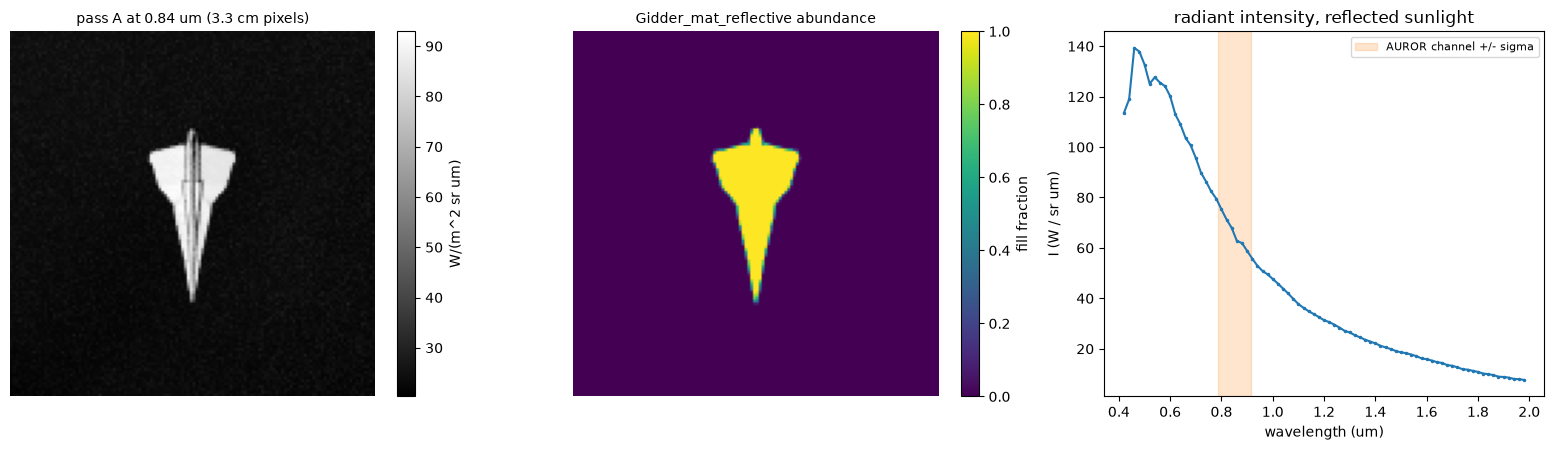

In [5]:
def intensity(L, truth, material_id):
    f = truth[f"Mat ID '{material_id}' Abundance [fraction]"]
    bg = f == 0
    L_bg = np.median(L[bg], axis=0)
    area = CLOSE_RANGE**2 * IFOV**2
    I = area * (L.sum(axis=(0, 1)) - L_bg * (1 - f).sum())
    A = area * f.sum()
    return I, A, L_bg, f


def band(x):
    """Weight a spectrum on CENTERS by the AUROR channel's Gaussian response."""
    w = np.exp(-0.5 * ((CENTERS - CH_CENTER) / CH_SIGMA) ** 2)
    return (w * x).sum() / w.sum()


I_A, A_A, Lbg_A, f_A = intensity(L_A, truth_A, "Gidder_mat_reflective")
k85 = int(np.argmin(abs(CENTERS - 0.85)))
mesh = f_A > 0.99
print(f"A_proj {A_A:.3f} m^2 (rasterized silhouette {A_TOP:.3f} m^2, ratio {A_A / A_TOP:.3f})")
print(f"mesh temperature truth {np.median(truth_A['Temperature [K]'][mesh]):.0f} "
      f"(-1 = not computed); sun fraction on the mesh {truth_A['Sun Fraction'][mesh].mean():.3f}")
print(f"at {CENTERS[k85]:.2f} um: L_bar = {I_A[k85] / A_A:.2f}, background {Lbg_A[k85]:.2f} W/(m^2 sr um); "
      f"I = {I_A[k85]:.2f} W/(sr um)")
print(f"AUROR-channel weighted: I = {band(I_A):.2f} W/(sr um), L_bar = {band(I_A) / A_A:.2f}, "
      f"terrain {band(Lbg_A):.2f} W/(m^2 sr um)")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
m = ax[0].imshow(L_A[:, :, k85], cmap="gray"); plt.colorbar(m, ax=ax[0], fraction=0.046, label="W/(m^2 sr um)")
ax[0].set_title(f"pass A at {CENTERS[k85]:.2f} um (3.3 cm pixels)", fontsize=10); ax[0].axis("off")
m = ax[1].imshow(f_A, cmap="viridis"); plt.colorbar(m, ax=ax[1], fraction=0.046, label="fill fraction")
ax[1].set_title("Gidder_mat_reflective abundance", fontsize=10); ax[1].axis("off")
ax[2].plot(CENTERS, I_A, ".-", ms=3)
ax[2].axvspan(CH_CENTER - CH_SIGMA, CH_CENTER + CH_SIGMA, color="C1", alpha=0.2, label="AUROR channel +/- sigma")
ax[2].set(xlabel="wavelength (um)", ylabel="I (W / sr um)", title="radiant intensity, reflected sunlight")
ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()
assert abs(A_A / A_TOP - 1) < 0.03, "projected area disagrees with the silhouette"

## Writing the `.int` file and the point source

`vehicle.int` holds $I(\lambda)$ at the 79 channel centres, two columns, wavelength [µm] and
radiant intensity [W sr⁻¹ µm⁻¹], increasing, per `int.html`. It adds two end points that repeat
the nearest value, at 0.41 and 2.00 µm, so the file spans the AUROR bandpass exactly. The
channel's response there is about 10⁻¹⁶ of its peak, so they don't matter.

The source definition follows `sources.html` ("User-Defined Sources", the GLIST method) and
`glist.html` ("Base Sources"), checked against the local 2026.38 docs:
- `vehicle_pointsource.mat`: `OPTICAL_DESCRIPTION = SOURCE`, `INTENSITY_FILENAME = vehicle.int`,
  `SOURCE_SHAPE = 0.0` (omni-directional; this $I$ is valid toward the overhead sensor only, which
  is the one direction this job looks from), `NORMALIZE_SHAPE = TRUE`.
- `vehicle_pointsource.glist`: a `<basesource><pointsource matid="vehicle_pointsource"/>`
  bundle with `<localmaterials>` and `search_paths="local"`, like the vehicle's own bundle. Its
  instance raises the source 0.25 m, just above the mesh's top (z max 0.186 m). At the model
  origin it would sit inside the opaque mesh it rides with, and the mesh could block it.
- In the scene, `lists/vehicle_pointsource.glist` instances that bundle with a copy of the
  vehicle's `<dynamicinstance>`, so the source is at the vehicle's origin at every time.

In [6]:
wl = np.r_[0.41, CENTERS, 2.00]
iv = np.r_[I_A[0], I_A, I_A[-1]]
assert np.all(np.diff(wl) > 0) and np.all(iv > 0)
INT_FILE = ASSETS / "vehicle_pointsource" / "vehicle.int"
INT_FILE.write_text("".join(f"{w:.3f}  {v:.6e}\n" for w, v in zip(wl, iv)))
print(f"wrote {INT_FILE.relative_to(PROJECT)}: {len(wl)} samples, {wl[0]}..{wl[-1]} um")
print(INT_FILE.read_text().splitlines()[22])

wrote notebooks/sidebars/vehicle_point_source/vehicle_pointsource/vehicle.int: 81 samples, 0.41..2.0 um
0.840  6.793255e+01


---
# Pass B — the received emitter, close up, with thermal prediction forced

The same close sensor on the received `Gidder_mat` (ρ = 0, 1500 K), rendered twice. The first
render uses the default flags, as every AUROR job so far has. The second adds `dirsig5
--force_temperature_prediction`, which `dirsig5 --help` describes as "Force temperature
prediction, even if the simulation does not cover the thermal spectrum". With the default flags,
DIRSIG predicts no temperatures for a 0.41–2.0 µm job. The temperature truth is −1 everywhere,
and the material's 1500 K is never turned into emission. With ρ = 0, the mesh is then perfectly
black. This pass shows that, and gives the emitter's intensity once emission is on.

In [7]:
lib_B = close_library("B_close_received", "Gidder_mat", False)
spec_B = spec_with_sensor_at("B_close_received", VEHICLE[2] + CLOSE_RANGE)
L_B0, _, truth_B0 = load(run_with("B_close_received", lib_B, spec_B), "close")
spec_Bf = spec_with_sensor_at("B_close_received_forced", VEHICLE[2] + CLOSE_RANGE)
L_Bf, _, truth_Bf = load(run_with("B_close_received_forced", lib_B, spec_Bf, force_temperature_prediction=None), "close")

for tag, L, t in (("default flags", L_B0, truth_B0), ("forced", L_Bf, truth_Bf)):
    I, A, Lbg, f = intensity(L, t, "Gidder_mat")
    on = f > 0.99
    print(f"{tag:14s}: mesh temperature truth {np.median(t['Temperature [K]'][on]):7.1f} K, "
          f"terrain {np.median(t['Temperature [K]'][f == 0]):6.1f} K; mesh L({CENTERS[k85]:.2f}) {np.median(L[:, :, k85][on]):8.2f}; "
          f"I (channel) {band(I):8.2f} W/(sr um)")
I_B, _, _, _ = intensity(L_Bf, truth_Bf, "Gidder_mat")
hc_k = 6.62607015e-34 * 2.99792458e8 / 1.380649e-23
planck = lambda lam_um, T: 2 * 6.62607015e-34 * 2.99792458e8**2 / (lam_um * 1e-6)**5 / np.expm1(hc_k / (lam_um * 1e-6 * T)) * 1e-6
print(f"blackbody 1500 K at {CENTERS[k85]:.2f} um: {planck(CENTERS[k85], 1500):.1f} W/(m^2 sr um)")
assert np.all(truth_B0["Temperature [K]"] == -1) and np.all(L_B0[truth_B0["Mat ID 'Gidder_mat' Abundance [fraction]"] > 0.99] == 0)

Material [Dummy] ID has already been set to [N/A], can't override.


Material [Dummy] ID has already been set to [N/A], can't override.


[warn] ../../../../../config_repo/scenes/tahoe/materials/emissivity/class1.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-2.550μm
[warn] ../../../../../config_repo/scenes/tahoe/materials/emissivity/class2.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-2.550μm
[warn] ../../../../../config_repo/scenes/tahoe/materials/emissivity/class3.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-2.550μm
[warn] ../../../../../config_repo/scenes/tahoe/materials/emissivity/class4.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-2.550μm
[warn] ../../../../../config_repo/scenes/tahoe/materials/emissivity/class5.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-2.550μm
[warn] ../../../../../config_repo/scenes/tahoe/materials/emissivity/class6.ems: has wavelengths 0.400-15.600μm, but

default flags : mesh temperature truth    -1.0 K, terrain   -1.0 K; mesh L(0.84)     0.00; I (channel)     1.97 W/(sr um)
forced        : mesh temperature truth  1500.0 K, terrain  261.3 K; mesh L(0.84)  3130.83; I (channel)  2961.40 W/(sr um)
blackbody 1500 K at 0.84 um: 3128.9 W/(m^2 sr um)


---
# Passes C, D, E — the full AUROR scene

All three use the unchanged AUROR run spec and platform, seed 42.
- **C** is the baseline: `config_repo/` as is.
- **D** adds the point source on the vehicle's motion, *alongside* the received mesh rather than
  replacing it. Under the job's default flags the mesh adds no light, so the point source can't
  double-count anything. The mesh still blocks its 0.3 % of the terrain behind it, which a bare
  point source would not. The reasons are in FINDINGS.md.
- **E** is the baseline with `--force_temperature_prediction`.

With the same seed, any pixel the source doesn't touch should come out identical between C and
D. That makes D − C the point source's own footprint, free of the scene's ~4 % per-pixel noise.

In [8]:
lib_C = mirror("C_full_baseline")
out_C = run_with("C_full_baseline", lib_C)

lib_D = mirror("D_full_pointsource")
src_dir = lib_D / SCENE_DIR / "geometry/bundles/vehicle_pointsource"
for f in (ASSETS / "vehicle_pointsource").iterdir():
    put(src_dir / f.name, f.read_text())
g = et.Element("geometrylist")
obj = et.SubElement(g, "object", enabled="true")
et.SubElement(et.SubElement(et.SubElement(obj, "basegeometry"), "glist"), "filename").text = \
    "bundles/vehicle_pointsource/vehicle_pointsource.glist"
dyn = copy.deepcopy(vehicle_glist.find(".//dynamicinstance"))
dyn.set("name", "vehicle_pointsource")
obj.append(dyn)
put(lib_D / SCENE_DIR / "geometry/lists/vehicle_pointsource.glist", et.ElementTree(g))
scene = et.parse(str(CONFIG_REPO / SCENE_DIR / "tahoe.scene"))
inc = et.SubElement(scene.getroot().find("geometrylist"), "geometrylistinclude", name="Vehicle point source", enabled="true")
inc.text = "lists/vehicle_pointsource.glist"
put(lib_D / SCENE_DIR / "tahoe.scene", scene)
out_D = run_with("D_full_pointsource", lib_D)

out_E = run_with("E_full_forced", mirror("E_full_forced"), force_temperature_prediction=None)

img = {k: load(o, "AurorNIROutput")[0][:, :, 0] for k, o in (("C", out_C), ("D", out_D), ("E", out_E))}
print("renders:", {k: v.shape for k, v in img.items()})

Material [Dummy] ID has already been set to [N/A], can't override.


Material [Dummy] ID has already been set to [N/A], can't override.


Material [Dummy] ID has already been set to [N/A], can't override.


[warn] ../../../../../config_repo/scenes/tahoe/materials/emissivity/class1.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-2.550μm
[warn] ../../../../../config_repo/scenes/tahoe/materials/emissivity/class2.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-2.550μm
[warn] ../../../../../config_repo/scenes/tahoe/materials/emissivity/class3.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-2.550μm
[warn] ../../../../../config_repo/scenes/tahoe/materials/emissivity/class4.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-2.550μm
[warn] ../../../../../config_repo/scenes/tahoe/materials/emissivity/class5.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-2.550μm
[warn] ../../../../../config_repo/scenes/tahoe/materials/emissivity/class6.ems: has wavelengths 0.400-15.600μm, but

renders: {'C': (500, 500), 'D': (500, 500), 'E': (500, 500)}


## What each change adds at 500 km

Each pass is read as an excess over the baseline, summed over the pixels it touches, in units
of one median pixel's signal ("pixel-equivalents"). The prediction for a point source of
channel-weighted intensity $I$, seen through the 50 → 550 km path, is
$\Delta = I\,\tau / (R^2\,\Omega\,L_{\text{terrain}})$, with:
- R = 500 km;
- τ ≈ 1 above 50 km (the same thin-air argument as above, over a longer path);
- $L_{\text{terrain}}$ the terrain radiance pass A saw from 51 km.

That terrain radiance has crossed essentially the whole atmosphere, as it has from 550 km. The
NIR image is in electrons, and the channel is narrow, so ratios of radiance and of signal agree
to well under 1 %.

The boresight passes through the shared corner of four pixels (rows/cols 249–250, numbered from
0), so the excess is summed over the 4 × 4 block around it. For scale, the noise quoted is the
spread of 4 × 4 sums of C at 2000 random places in the frame. It includes terrain relief as well
as sampling noise, so it is the scale against which a target in a *single* image would have to
stand out. It is not the error of D − C, which is exactly zero wherever the two seeded renders
stay identical.

pixels that differ, D vs C: 0 at []
pixels that differ, E vs C: 2
4x4 block noise (std of 4x4 sums, in pixel-equivalents): 1.184
D  point source, reflected (rho 0.30): rendered +0.0000, predicted +0.0115 pixel-equivalents
E  received emitter, thermal forced  : rendered +0.5625, predicted +0.5094 (FINDINGS 2026-10-06 expected +0.49 over its 2x2 block)


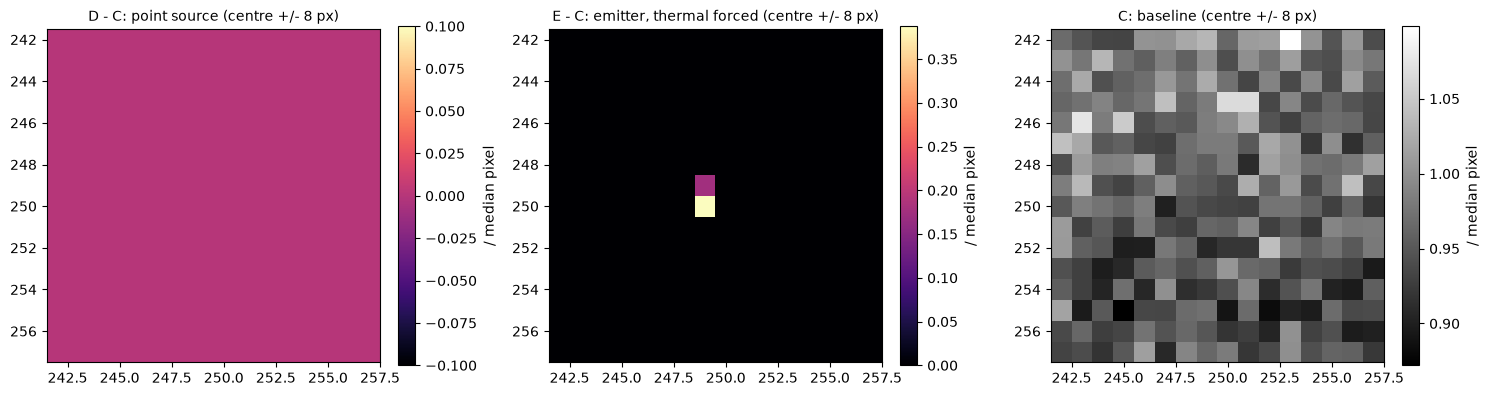

In [9]:
c = img["C"].shape[0] // 2
blk = (slice(c - 2, c + 2), slice(c - 2, c + 2))
med = np.median(img["C"])
excess = {k: (img[k] - img["C"])[blk].sum() / med for k in ("D", "E")}
touched_D = np.argwhere(img["D"] != img["C"])
rng = np.random.default_rng(0)
blocks = [img["C"][y:y + 4, x:x + 4].sum() / med for y, x in rng.integers(10, 486, size=(2000, 2))]
noise = np.std(blocks)

pred_D = band(I_A) / (RANGE**2 * IFOV**2 * band(Lbg_A))
pred_E = band(I_B) / (RANGE**2 * IFOV**2 * band(Lbg_A))
print(f"pixels that differ, D vs C: {len(touched_D)} at {touched_D[:8].tolist()}")
print(f"pixels that differ, E vs C: {(img['E'] != img['C']).sum()}")
print(f"4x4 block noise (std of 4x4 sums, in pixel-equivalents): {noise:.3f}")
print(f"D  point source, reflected (rho 0.30): rendered {excess['D']:+.4f}, predicted {pred_D:+.4f} pixel-equivalents")
print(f"E  received emitter, thermal forced  : rendered {excess['E']:+.4f}, predicted {pred_E:+.4f} "
      f"(FINDINGS 2026-10-06 expected +0.49 over its 2x2 block)")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
for a, (k, title) in zip(ax, (("D", "D - C: point source"), ("E", "E - C: emitter, thermal forced"), ("C", "C: baseline"))):
    sub = (img[k] - img["C"] if k != "C" else img["C"])[c - 8:c + 8, c - 8:c + 8] / med
    m = a.imshow(sub, cmap="magma" if k != "C" else "gray", extent=(c - 8.5, c + 7.5, c + 7.5, c - 8.5))
    plt.colorbar(m, ax=a, fraction=0.046, label="/ median pixel")
    a.set_title(title + " (centre +/- 8 px)", fontsize=10)
plt.tight_layout(); plt.show()

## Why D adds nothing: DIRSIG5 does not render a directly viewed point source

D − C is exactly zero, so the source never reached the image. The source *is* in the compiled
scene: `scene2hdf` read `vehicle.int`, and the scene HDF's `Objects/Sources` lists
`vehicle_pointsource` with its spectral curve. The cell below is a control on DIRSIG's own
`Sources1` demo, unzipped from the install into the work directory. It renders the demo twice:
- *as shipped*: its point sources a few metres above a reflective plate;
- *with the plate scene dropped from the job*: the same six sources, all inside the field of a
  sensor looking down from 100 m.

If DIRSIG5 rendered directly viewed sources, the second image would have bright pixels at the
source positions. In `sources.html`, the direct-viewing description and its `viewdirect` option
both sit under "Relevant Options (DIRSIG4 only)".

In [10]:
import subprocess, zipfile, json as _json
demo = WORK / "control_Sources1"
zipfile.ZipFile(DIRSIG_HOME / "demos/zips/Sources1.zip").extractall(demo)
demo = demo / "Sources1"
for sc in ("plate.scene", "lights.scene"):
    subprocess.run(["scene2hdf", sc], cwd=demo, check=True, capture_output=True)
jobs = _json.loads((demo / "multi_scene.jsim").read_text())
lights_only = copy.deepcopy(jobs)
lights_only[0]["scene_list"] = [s for s in jobs[0]["scene_list"] if "lights" in s["inputs"]]
(demo / "lights_only.jsim").write_text(_json.dumps(lights_only, indent=2))
for name, jsim in (("with_plate", "multi_scene.jsim"), ("lights_only", "lights_only.jsim")):
    (demo / name).mkdir()
    subprocess.run(["dirsig5", jsim, f"--output_folder={name}"], cwd=demo, check=True, capture_output=True)
    x = np.asarray(open_image(str(demo / name / "demo.img.hdr")).load(), dtype=float)
    print(f"Sources1 {name:12s}: max {x.max():.3e} W/(cm^2 sr), pixels > 0: {(x.sum(axis=2) > 0).sum()} of {x.shape[0] * x.shape[1]}")

Sources1 with_plate  : max 1.456e-06 W/(cm^2 sr), pixels > 0: 29044 of 76800


Sources1 lights_only : max 0.000e+00 W/(cm^2 sr), pixels > 0: 0 of 76800


## `secondarysources.threshold`

The prompt asks whether DIRSIG's source-rejection threshold (default 1.0 × 10⁻⁵) would drop this
source. In this setup the threshold is not the reason D adds nothing:

* In `sources.html`, `secondarysources.threshold` sits under "Relevant Options (DIRSIG4 only)",
  set through a `.options` file. These AUROR jobs are DIRSIG5 and have no `.options` file.
* DIRSIG5's counterpart is `dirsig5 --source_threshold` ("Set the optional radiance threshold
  for secondary sources"). Its help text gives no default, and these jobs don't pass it.
* The threshold governs the *indirect* term, a source's light reflected off surfaces. What this
  job needs is the *direct* term, and the control above shows DIRSIG5 doesn't render that.
* The indirect term is negligible here regardless. The irradiance this source puts on the
  terrain 50 km below is $I/R^2$, computed next, which is far below the sun's ~10³ W m⁻² µm⁻¹.

In [11]:
E_ground = band(I_A) / VEHICLE[2]**2
print(f"point source irradiance at the terrain: {E_ground:.2e} W/(m^2 um); reflected radiance "
      f"(rho 0.3 / pi) {0.3 / np.pi * E_ground:.2e} W/(m^2 sr um), against terrain {band(Lbg_A):.1f}")

point source irradiance at the terrain: 2.68e-08 W/(m^2 um); reflected radiance (rho 0.3 / pi) 2.56e-09 W/(m^2 sr um), against terrain 21.8


## Summary and close-out

In [12]:
assert fingerprint(CONFIG_REPO) == REPO_BEFORE, "config_repo changed"
print(f"config_repo fingerprint unchanged ({len(REPO_BEFORE)} paths)")
print(f"geometry : {GSD:.2f} m pixels at the vehicle; silhouette {A_TOP:.3f} m^2 ({A_TOP / GSD**2:.2%} of a pixel)")
print(f"pass A   : rho 0.30, A_proj {A_A:.3f} m^2, L_bar {band(I_A) / A_A:.2f} W/(m^2 sr um), "
      f"I {band(I_A):.2f} W/(sr um) (AUROR-channel weighted)")
print(f"pass B   : emitter I {band(I_B):.1f} W/(sr um) with thermal forced; 0 without")
print(f"pass D   : point source {excess['D']:+.4f} pixel-equivalents, {len(touched_D)} pixels changed "
      f"(would be {pred_D:+.4f} if DIRSIG5 rendered it; 4x4 scale {noise:.3f})")
print(f"pass E   : emitter {excess['E']:+.4f} pixel-equivalents (predicted {pred_E:+.4f}; FINDINGS expected +0.49)")

config_repo fingerprint unchanged (36 paths)
geometry : 16.34 m pixels at the vehicle; silhouette 0.827 m^2 (0.31% of a pixel)
pass A   : rho 0.30, A_proj 0.826 m^2, L_bar 81.05 W/(m^2 sr um), I 66.98 W/(sr um) (AUROR-channel weighted)
pass B   : emitter I 2961.4 W/(sr um) with thermal forced; 0 without
pass D   : point source +0.0000 pixel-equivalents, 0 pixels changed (would be +0.0115 if DIRSIG5 rendered it; 4x4 scale 1.184)
pass E   : emitter +0.5625 pixel-equivalents (predicted +0.5094; FINDINGS expected +0.49)
